In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score, 
    precision_recall_curve, average_precision_score
)
import joblib

In [2]:
X_test = pd.read_csv('../data/X_test_week4.csv')  
y_test = pd.read_csv('../data/y_test_week4.csv')

In [3]:
best_model = joblib.load('../data/final_model_week5.pkl')


In [4]:
y_pred_class = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:,1]

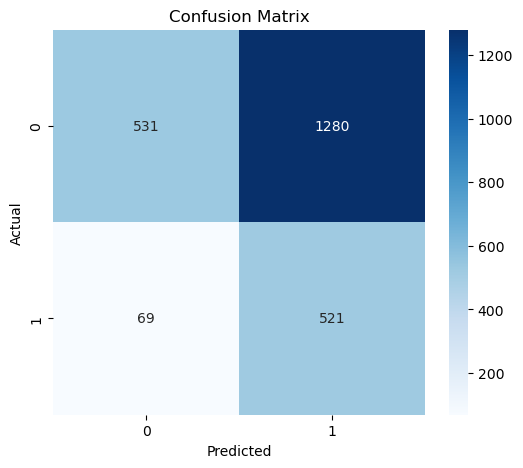

In [5]:
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

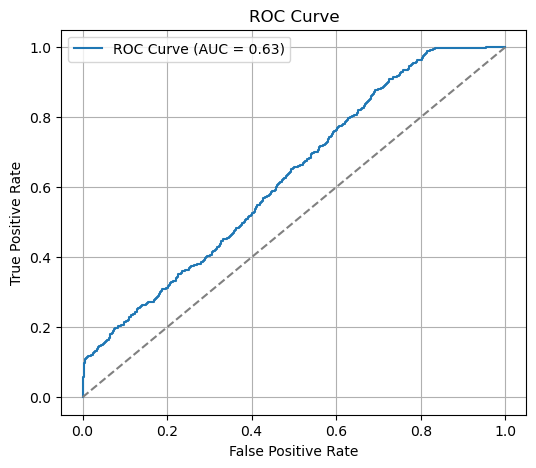

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

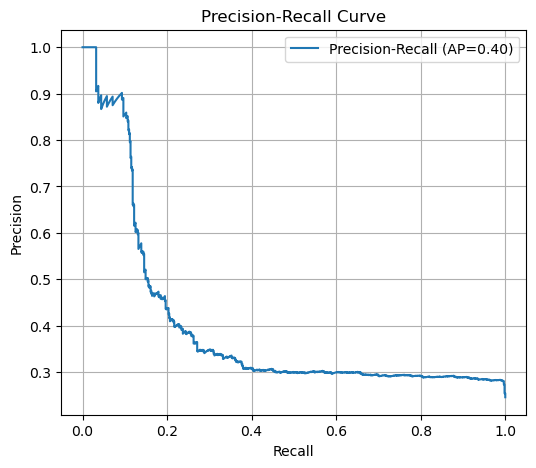

In [7]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"Precision-Recall (AP={avg_precision:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

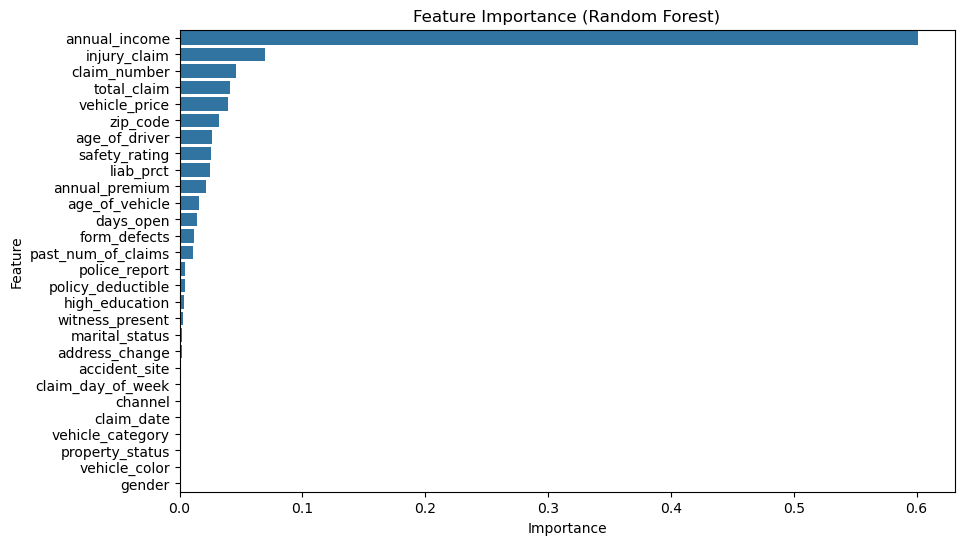

In [8]:
if hasattr(best_model, 'feature_importances_'):
    feature_importances = best_model.feature_importances_
    feature_names = X_test.columns
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10,6))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title("Feature Importance (Random Forest)")
    plt.show()

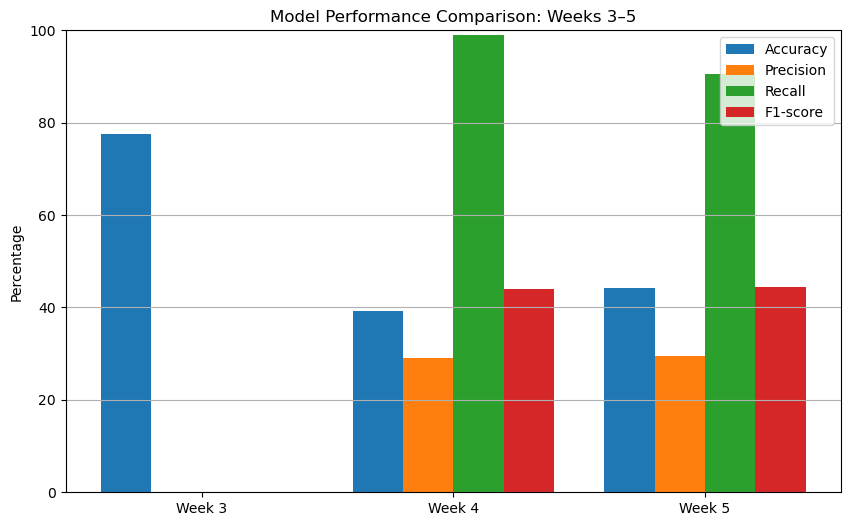

In [9]:

weeks = ['Week 3', 'Week 4', 'Week 5']
accuracy = [77.53, 39.19, 44.25]
precision = [np.nan, 29.0, 29.39] 
recall = [np.nan, 0.99*100, 0.9047*100]  
f1 = [np.nan, 44.0, 44.36]

x = np.arange(len(weeks))
width = 0.2

plt.figure(figsize=(10,6))
plt.bar(x - width*1.5, accuracy, width, label='Accuracy')
plt.bar(x - width/2, precision, width, label='Precision')
plt.bar(x + width/2, recall, width, label='Recall')
plt.bar(x + width*1.5, f1, width, label='F1-score')

plt.xticks(x, weeks)
plt.ylabel("Percentage")
plt.title("Model Performance Comparison: Weeks 3–5")
plt.ylim(0, 100)
plt.legend()
plt.grid(axis='y')
plt.show()
